In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import logging

from tools.robots import Robot, DoubleIntegrator, SingleIntegrator
# from tools.robots.robot import Robot
# from tools.robots.double_integrator import DoubleIntegrator
# from tools.robots.single_integrator import SingleIntegrator

from tools.planners.mcgs import MCGSPlanner, NodePayload, EdgePayload
from tools.envs.frozen_lake_continuous import FrozenLakeEnv

from tools.utils.plot_graph import plot_graph_2d, plot_spacetime_graph_3d, plot_graph_2d_live
from tools.envs.frozen_lake_continuous import FrozenLakeEnv

import rustworkx as rx
from rustworkx.visualization import mpl_draw
# from rustworkx import Pos2DMapping
# %matplotlib widget
%matplotlib inline



In [2]:
# only from mcgs.py
logging.basicConfig(level=logging.WARNING, format='%(asctime)s - %(levelname)s - %(message)s')


[[ 0 20]
 [ 0 20]]


/home/christoph/Dokumente/research/projects/dec-mcgs/tools/envs/frozen_lake_continuous.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


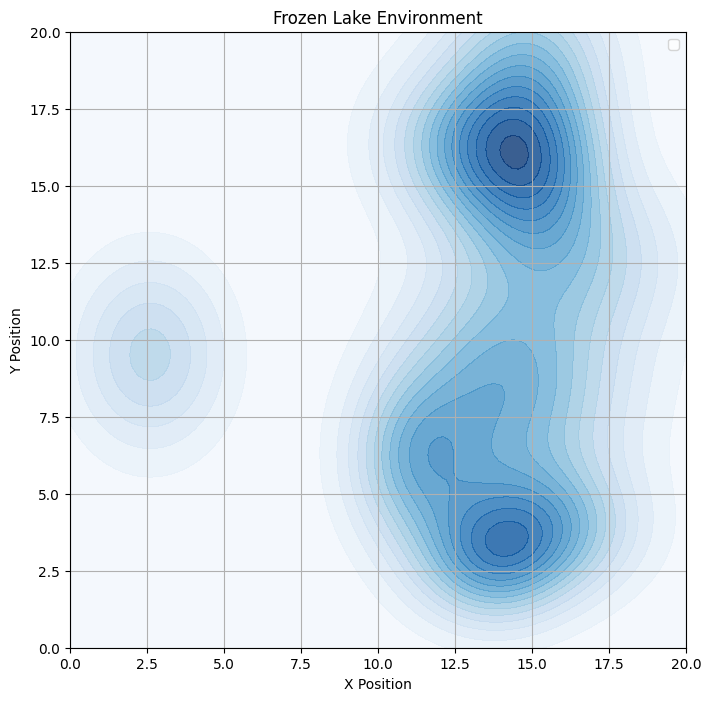

In [3]:
env = FrozenLakeEnv(size=20,
                     n_puddles=12,
                     n_obstacles=0)
print(env.bbox)
env.reset(seed=42)
env.render(robots=[])

In [4]:
start_pos = np.array([2.5, 2.5])
goal_pos = np.array([17.5, 17.5])

def reward_function(state):
    # Example reward function: negative distance to the goal position
    c_time = 1*state['time']
    c_pos = np.linalg.norm(state['position'] - goal_pos, ord=2)
    return - np.sum([c_time, c_pos])

In [5]:
max_velocity = 2.0
rob = SingleIntegrator(id=0, 
                       name="SingleIntegrator", 
                       dt=1.0, 
                       max_velocity=max_velocity,
                       state_goal={'position': goal_pos, 
                                   'time': np.array(30.0)},
                       action_sampler_method='uniform',)

root_state = {'position': start_pos, 
              'time': np.array(0.0)}

rob.state = root_state
print(rob)

root_encoded_state = rob.encode_state(root_state)
print("Encoded root state:", root_encoded_state)
print("Encoded goal state:", rob.encode_state(rob.state_goal))


Robot SingleIntegrator (ID: 0) with state {'position': array([2.5, 2.5]), 'time': array(0.)} and bounding box None
Encoded root state: [1.25 1.25 0.  ]
Encoded goal state: [ 8.75  8.75 30.  ]


In [6]:
# max_velocity = 1.0
# max_acceleration = 1.0
# rob = DoubleIntegrator(id=0, 
#                        name="DoubleIntegrator", 
#                        dt=1.0, 
#                        max_velocity=max_velocity,
#                        max_acceleration=max_acceleration,
#                        state_goal={'position': goal_pos, 
#                                    'velocity' : .5*np.array([1.0, 1.0]),
#                                    'time': np.array(25.0)},
#                        action_sampler_method='uniform',)

# root_state = {'position': start_pos, 
#               'velocity': np.array([0.0, 0.0]), 
#               'time': np.array(0.0)}

# rob.state = root_state
# print(rob)

# root_encoded_state = rob.encode_state(root_state)
# print("Encoded root state:", root_encoded_state)
# print("Encoded goal state:", rob.encode_state(rob.state_goal))


In [7]:
# MCGS Planner
mcgs_planner = MCGSPlanner(robot=rob, 
                        reward_function=reward_function,
                        max_iterations=100, 
                        expand_n_times=1,
                        kappa=1.6, # 1.6
                        alpha=0.3, # 0.3
                        k=8,
                        radius_threshold=1.8, # 1.8,
                        abstraction_refinement_exponent=-0.1,
                        c_uct=0.4)

# MCTS Planner

# mcgs_planner = MCGSPlanner(robot=rob, 
#                         reward_function=reward_function,
#                         max_iterations=100, 
#                         kappa=1.8, 
#                         alpha=.8,
#                         k=0,
#                         radius_threshold=0.0,
#                         c_uct=0.8)

In [8]:
mcgs_planner.reset_graph()
mcgs_planner.plan(iterations=10)


x: [2.5 2.5], t: 0.0, u: [0.73966794 0.5075343 ], f: [0. 0.]
x: [2.5 2.5], t: 0.0, u: [-0.13370572  1.50543007], f: [0. 0.]
x: [2.5 2.5], t: 0.0, u: [-0.86211424 -0.63800449], f: [0. 0.]
x: [2.36629428 4.00543007], t: 1.0, u: [0.80474148 0.06300361], f: [0. 0.]
x: [3.23966794 3.0075343 ], t: 1.0, u: [-0.35589312  0.27890205], f: [0. 0.]
x: [2.36629428 4.00543007], t: 1.0, u: [0.02676064 0.11099781], f: [0. 0.]
x: [2.36629428 4.00543007], t: 1.0, u: [-1.18123715  0.07555632], f: [0. 0.]
x: [3.23966794 3.0075343 ], t: 1.0, u: [ 1.20112491 -0.29082208], f: [0. 0.]
x: [2.5 2.5], t: 0.0, u: [-1.38618825  0.60782597], f: [0. 0.]
x: [3.23966794 3.0075343 ], t: 1.0, u: [0.37270333 0.52462995], f: [0. 0.]


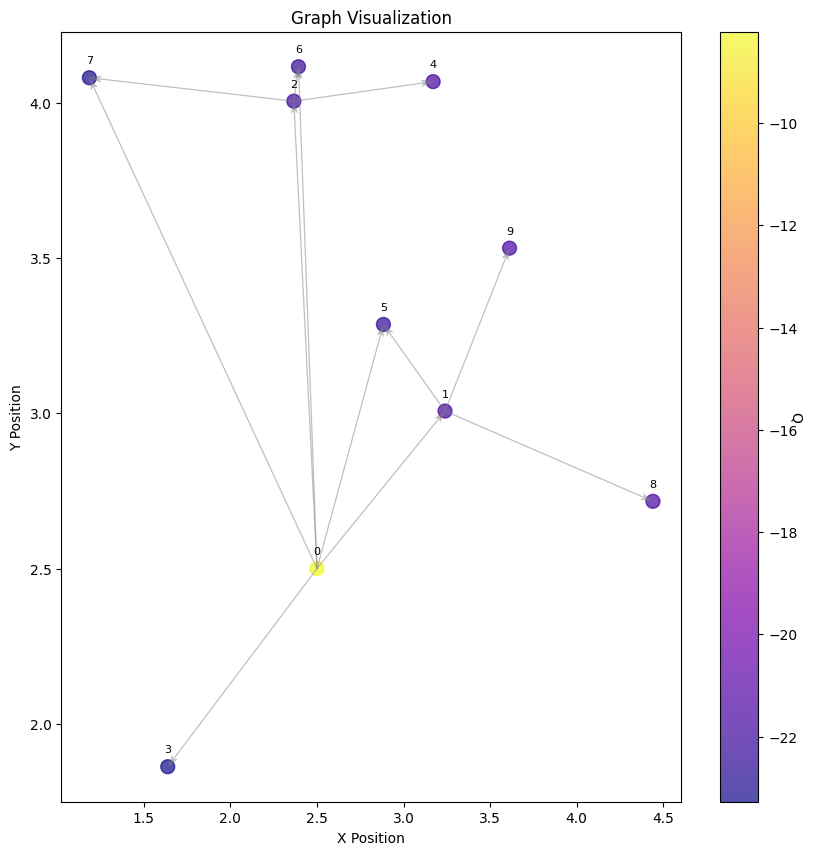

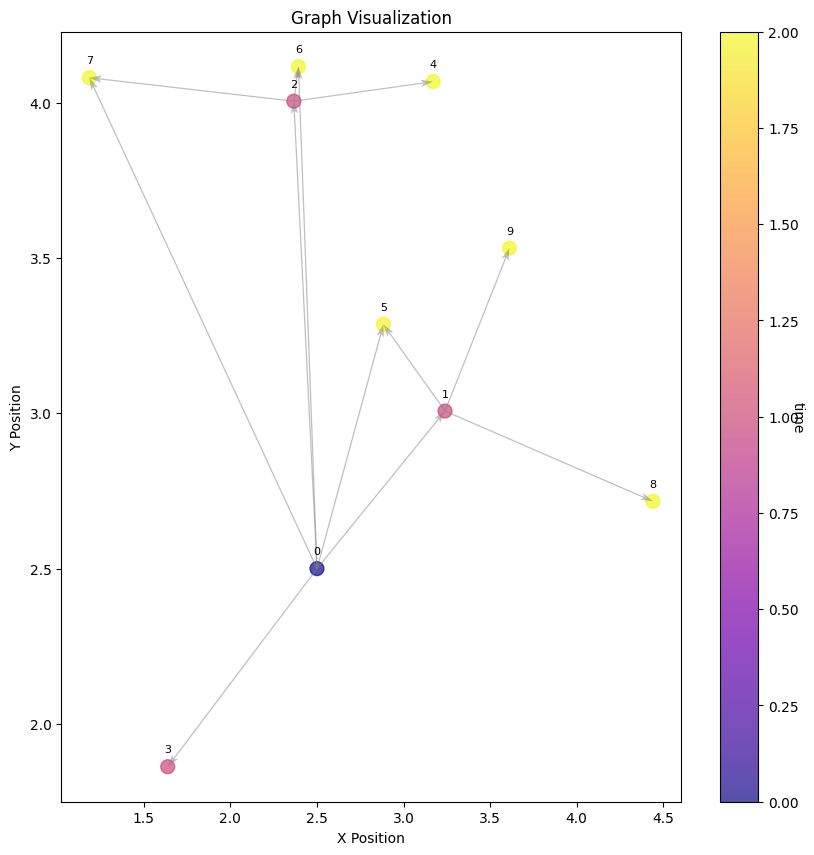

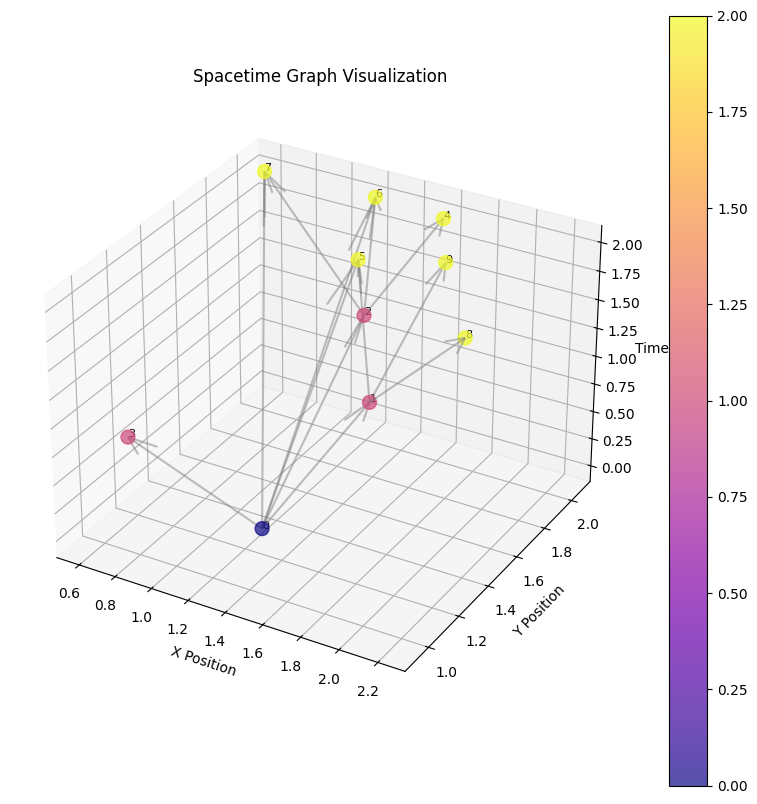

In [9]:
plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, bbox=None)
plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='time', plot_values=False, bbox=None)
plot_spacetime_graph_3d(mcgs_planner.graph, mcgs_planner.robot, plot_labels=True, plot_time=True,)
plt.show()

In [10]:
mcgs_planner.plan(iterations=100)


x: [3.61237127 3.53216425], t: 2.0, u: [ 0.1536524  -1.07591777], f: [0. 0.]
x: [4.44079285 2.71671222], t: 2.0, u: [ 0.85212746 -0.20868591], f: [0. 0.]
x: [4.44079285 2.71671222], t: 2.0, u: [-1.10519562  1.43927573], f: [0. 0.]
x: [2.88377481 3.28643635], t: 2.0, u: [ 1.0745194  -0.96298909], f: [0. 0.]
x: [4.44079285 2.71671222], t: 2.0, u: [-0.46414235 -1.84370449], f: [0. 0.]
x: [3.23966794 3.0075343 ], t: 1.0, u: [-1.11466622  0.60469481], f: [0. 0.]
x: [3.33559723 4.15598795], t: 3.0, u: [-0.46052831  0.88903653], f: [0. 0.]
x: [3.61237127 3.53216425], t: 2.0, u: [ 0.93419979 -0.50017245], f: [0. 0.]
x: [3.61237127 3.53216425], t: 2.0, u: [1.14854788 0.37260265], f: [0. 0.]
x: [4.76091915 3.9047669 ], t: 3.0, u: [ 0.14685222 -1.08336257], f: [0. 0.]
x: [4.54657106 3.0319918 ], t: 3.0, u: [ 0.0106967  -0.11940415], f: [0. 0.]
x: [4.76091915 3.9047669 ], t: 3.0, u: [0.52912273 0.17365855], f: [0. 0.]
x: [4.76091915 3.9047669 ], t: 3.0, u: [ 0.0114561  -0.02343039], f: [0. 0.]
x: 

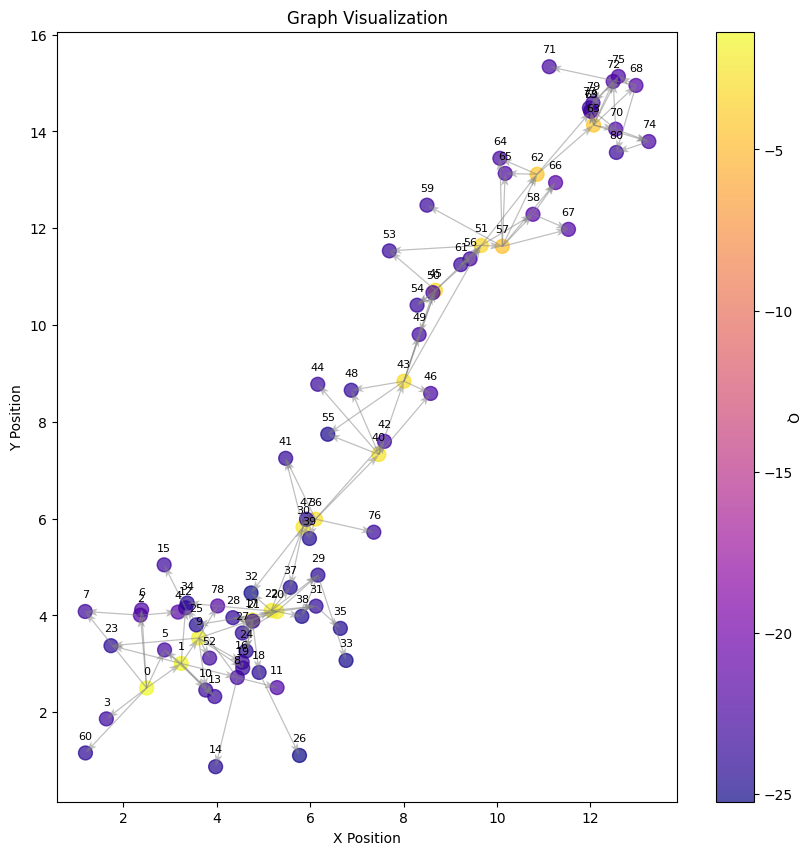

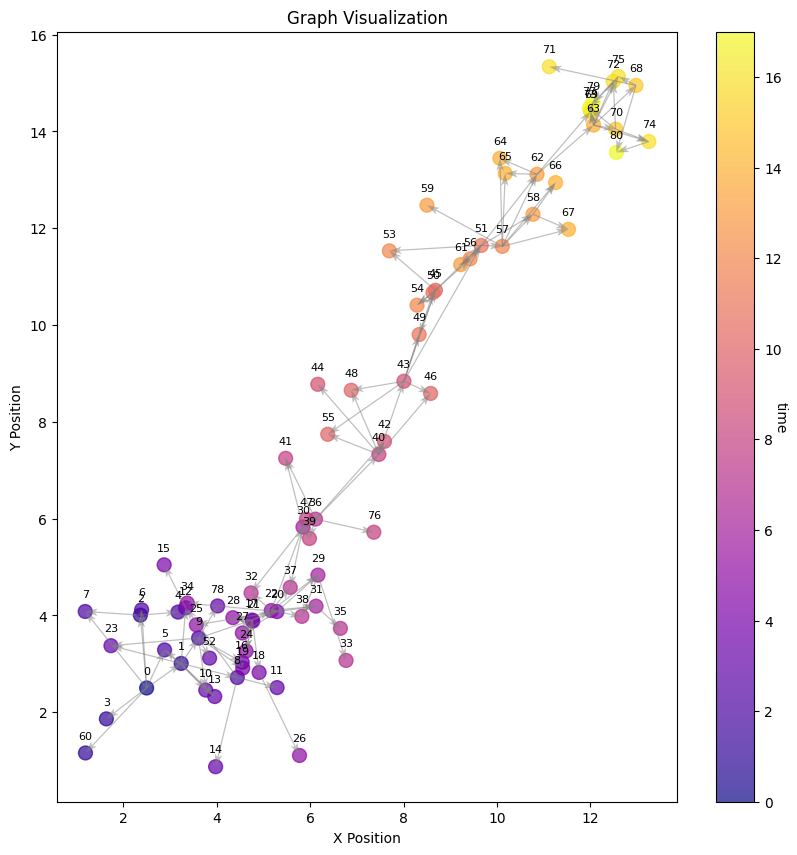

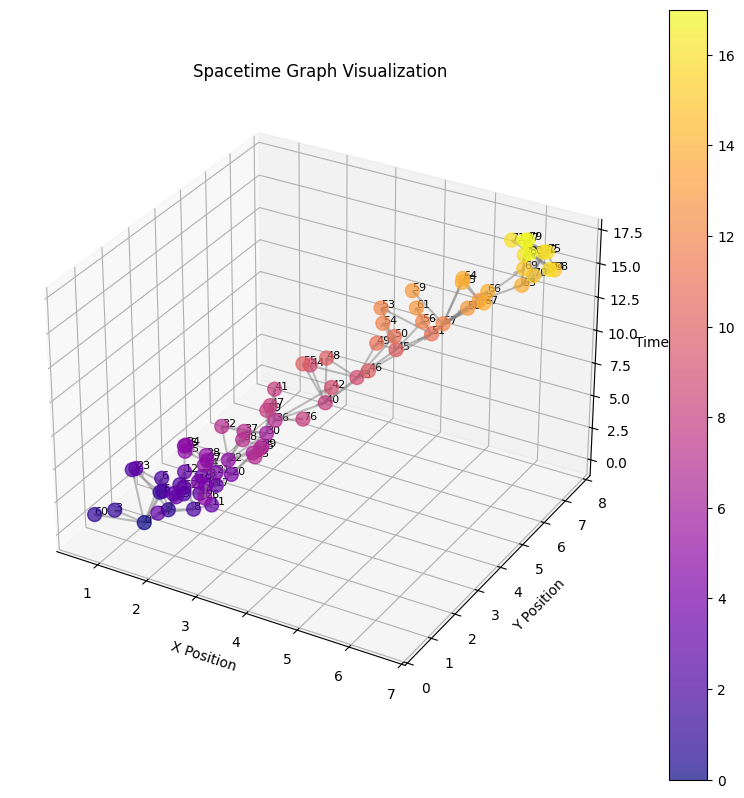

In [11]:
plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, bbox=None)
plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='time', plot_values=False, bbox=None)
plot_spacetime_graph_3d(mcgs_planner.graph, mcgs_planner.robot, plot_labels=True, plot_time=True,)
plt.show()

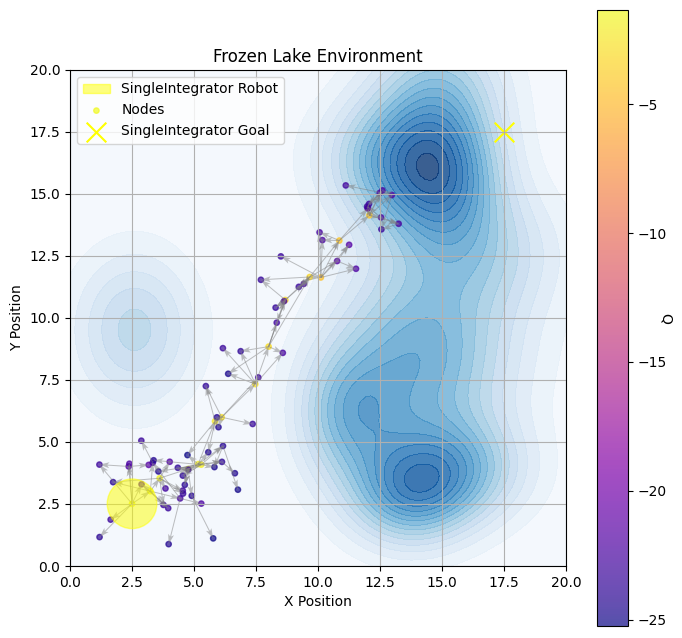

In [12]:
%matplotlib inline
fig = env.render(robots=[rob], 
           planners=[mcgs_planner], 
           render_tree=True)
plt.show()

In [13]:
atol = 0.0
rtol = .2

plan = mcgs_planner.yield_plan(atol=atol, rtol=rtol)
print(plan)
print(mcgs_planner.graph[plan[-1]].state)
print("Finished: ", rob.is_finished(atol=atol, rtol=rtol, state=mcgs_planner.graph[plan[-1]].state))

[0, 1, 9, 17, 20, 22, 30, 36, 40, 43, 45, 51, 57, 62, 63, 69, 79]
{'position': array([12.05509561, 14.59026736]), 'time': np.float64(17.0)}
Finished:  False


In [14]:
mcgs_planner.reset_graph()


In [15]:
def step(action: EdgePayload):
    current_state = mcgs_planner.robot.state
    mcgs_planner.robot.step(action.action + 0.3 *np.random.normal(0, 1, size=action.action.shape))
    new_state = mcgs_planner.robot.state
    print("Current state:", current_state)
    print("New state:", new_state)

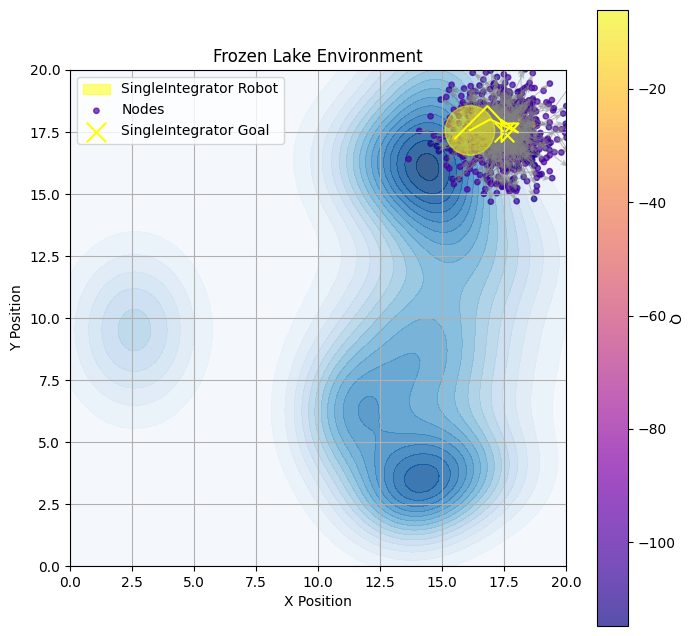

x: [16.12383964 17.56341603], t: 99.0, u: [1.42386091 0.02793154], f: [0. 0.]
Current state: {'position': array([16.12383964, 17.56341603]), 'time': np.float64(99.0)}
New state: {'position': array([17.54770055, 17.59134758]), 'time': np.float64(100.0)}
New node: 212 with successors:  NodeIndices[]


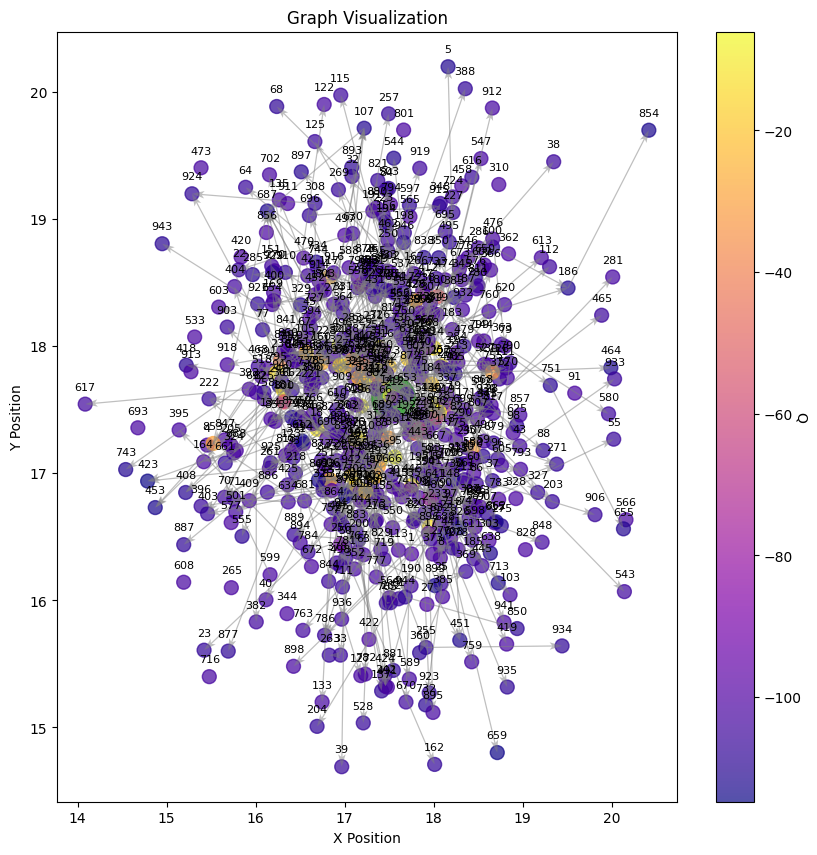

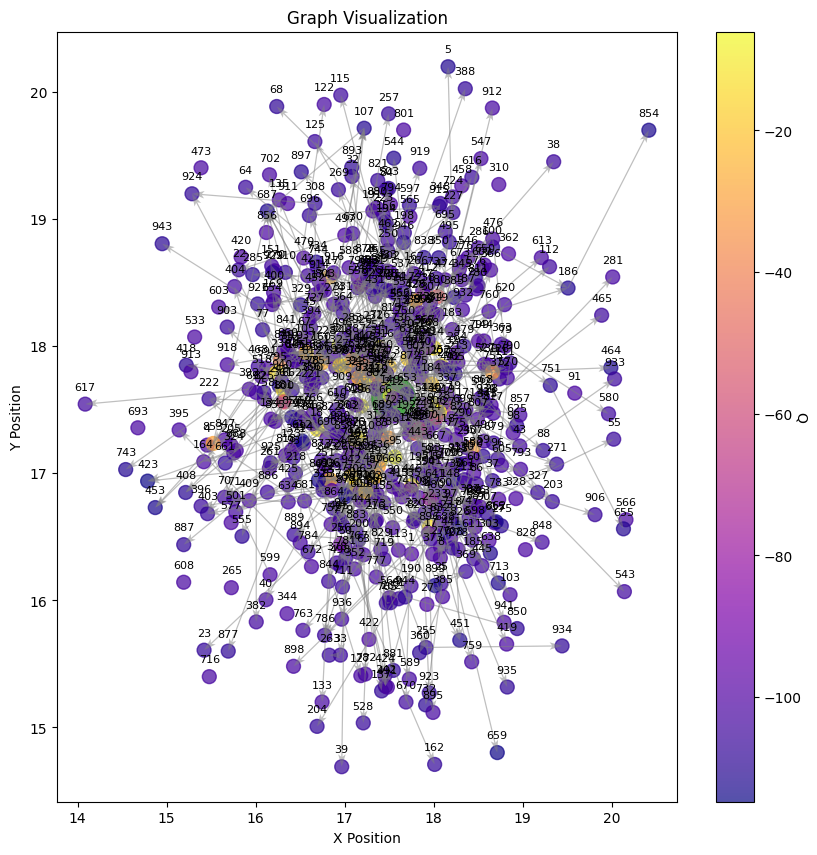

In [16]:
mcgs_planner.reset_graph()

# Bootstrap:
mcgs_planner.plan(iterations=10, expand_n_times=10)

%matplotlib inline

atol = 0.0
rtol = .1

fig = env.render_live(robots=[mcgs_planner.robot], 
                            planners=[mcgs_planner], 
                            render_tree=True)
for i in range(100):
    print("Iteration:", i)

    mcgs_planner.plan(iterations=100, expand_n_times=1)
    
    plan = mcgs_planner.yield_plan(atol=atol, rtol=rtol, max_length=10)
    mcgs_planner.update_trajectory_plan(plan)
    print(plan)
    assert len(plan) > 1, "Plan does not include successor node!"
    optimal_action = mcgs_planner.graph.get_edge_data(mcgs_planner.root_node_id, plan[1])
    print("Optimal action:", optimal_action.action, " from ", mcgs_planner.root_node_id, " to ", plan[1], " at ", mcgs_planner.graph[plan[1]].state)
    # plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot)
    # fig = plot_graph_2d_live(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot, bbox=env.bbox)

    fig = env.render_live(robots=[mcgs_planner.robot], 
                        planners=[mcgs_planner], 
                        render_tree=True, 
                        fig=fig,
                        interval=10)

    step(optimal_action)
    mcgs_planner.update_planner()
    print("New node:", mcgs_planner.root_node_id, "with successors: ", mcgs_planner.graph.successor_indices(mcgs_planner.root_node_id))
    
    
    mcgs_planner.garbage_collector.collect_garbage(timestamp_threshold=mcgs_planner.robot.state['time'], root_node_id=mcgs_planner.root_node_id)
    if mcgs_planner.robot.is_finished(atol=atol, rtol=rtol, state=mcgs_planner.graph[mcgs_planner.root_node_id].state):
        fig = env.render_live(robots=[mcgs_planner.robot], 
                        planners=[mcgs_planner], 
                        render_tree=True, 
                        fig=fig,
                        interval=10)
        
        print(f"Robot has reached the goal state after {i} iterations!")
        break


plot_graph_2d(mcgs_planner.graph, plot_labels=True, scatter_mode='Q', plot_values=False, robot=mcgs_planner.robot)